In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

In [6]:
import pandas as pd

data = pd.read_csv('/content/breast-cancer.csv')
display(data.head())

# Take only first two features for 2D visualization
# Assuming 'id' is column 0 and 'diagnosis' is column 1,
# so the first two features are columns 2 and 3.
X = data.iloc[:, 2:4]
y = data['diagnosis']

print("Shape of X:", X.shape)
print("Classes:", np.unique(y))

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Shape of X: (569, 2)
Classes: ['B' 'M']


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
svm_linear = SVC(kernel='linear', C=1)
svm_linear.fit(X_train, y_train)

print("Linear SVM Training Accuracy:",
      svm_linear.score(X_train, y_train))
print("Linear SVM Testing Accuracy:",
      svm_linear.score(X_test, y_test))

Linear SVM Training Accuracy: 0.8819095477386935
Linear SVM Testing Accuracy: 0.9005847953216374


In [10]:
svm_rbf = SVC(kernel='rbf', C=1, gamma=0.1)
svm_rbf.fit(X_train, y_train)

print("RBF SVM Training Accuracy:",
      svm_rbf.score(X_train, y_train))
print("RBF SVM Testing Accuracy:",
      svm_rbf.score(X_test, y_test))

RBF SVM Training Accuracy: 0.9045226130653267
RBF SVM Testing Accuracy: 0.9122807017543859


In [11]:
def plot_decision_boundary(model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.title(title)
    plt.show()

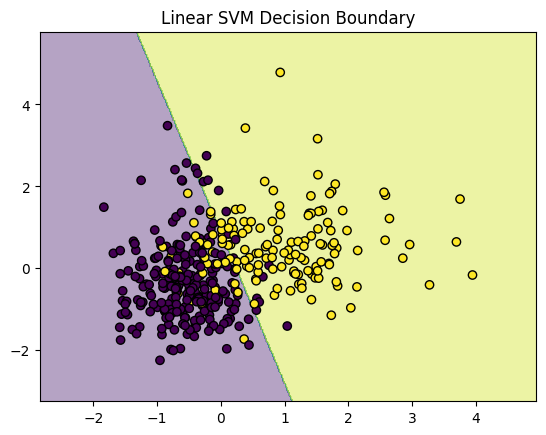

In [13]:
# Create a mapping for string labels to numerical values
label_mapping = {'B': 0, 'M': 1}

# Convert y_train to numerical for plotting
y_train_numeric = y_train.map(label_mapping)

# Redefine plot_decision_boundary to handle string predictions and convert them
def plot_decision_boundary_fixed(model, X, y_numeric_for_scatter, title, label_map):
    h = 0.02
    # Determine the range for the grid based on X, which is already numeric
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    # Make predictions (these will be strings if the model was trained on strings)
    Z_str = model.predict(np.c_[xx.ravel(), yy.ravel()])

    # Convert string predictions to numerical values using the label_map
    Z_numeric = np.array([label_map[label] for label in Z_str])
    Z_numeric = Z_numeric.reshape(xx.shape)

    plt.contourf(xx, yy, Z_numeric, alpha=0.4)
    # Use the already numeric y for scatter plot
    plt.scatter(X[:, 0], X[:, 1], c=y_numeric_for_scatter, edgecolors='k')
    plt.title(title)
    plt.show()

# Call the fixed plotting function
plot_decision_boundary_fixed(svm_linear, X_train, y_train_numeric,
                           "Linear SVM Decision Boundary", label_mapping)

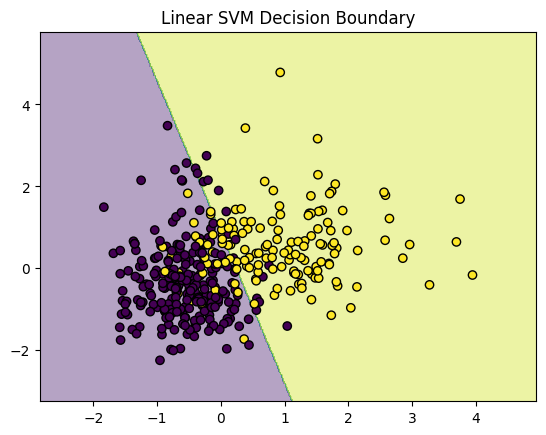

In [15]:
plot_decision_boundary_fixed(svm_linear, X_train, y_train_numeric,
                       "Linear SVM Decision Boundary", label_mapping)

In [16]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

grid = GridSearchCV(SVC(), param_grid, refit=True, cv=5)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross-validation Score:", grid.best_score_)

Best Parameters: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
Best Cross-validation Score: 0.9018354430379747


In [17]:
scores = cross_val_score(grid.best_estimator_,
                         X_train, y_train, cv=5)

print("Cross Validation Scores:", scores)
print("Mean Accuracy:", scores.mean())

Cross Validation Scores: [0.9        0.9        0.975      0.84810127 0.88607595]
Mean Accuracy: 0.9018354430379747


In [18]:
best_model = grid.best_estimator_

print("Final Test Accuracy:",
      best_model.score(X_test, y_test))

Final Test Accuracy: 0.9064327485380117
